# **Project-8 - Credit Card Fraud Detection**

## **Problem Statement**

1. A credit card is a small thin plastic or fiber card that incorporates
information about the person such as a picture or signature and the
person’s name on it to charge purchases and services to his linked
account. Charges are debited regularly. Nowadays, card data is read by
ATMs, swiping machines, store readers, banks and online transactions.
2. Each card has a unique card number which is very important. Its security
mainly relies on the physical security of the card and also the privacy of the
credit card number. There is a rapid growth in credit card transactions
which has led to substantial growth in scam cases.
3. Credit card fraud is expanding heavily because fraud financial loss is
increasing drastically. Multiple data mining and statistical techniques are used to catch fraud. Therefore, detection of fraud using efficient and secured methods is very important.

## **About the dataset**

The dataset contains transactions made by credit cards in September 2013 by European cardholders.  

This dataset presents transactions that occurred in two days, where we have 492 frauds out of 284,807 transactions. The dataset is highly imbalanced, the positive class (frauds) account for 0.172% of all transactions.  

It contains only numerical input variables which are the result of a PCA transformation. Unfortunately due to confidentiality issues, we cannot provide the original features and more background information about the data. Features V1, V2, V3...V28 are the principal components obtained with PCA, the only features which have not been transformed with PCA are `Time` and `Amount`. Feature `Time` contains seconds elapsed between each transaction and the first transaction in the dataset. The feature `Amount` is the transaction amount, this feature can be used for example-dependent cost-sensitive learning. Feature `Class` is the response variable and it takes value 1 in case of fraud and 0 otherwise.

## **Initial Setup**

### **Import the libraries**

In [71]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score, roc_curve, precision_recall_curve, f1_score, confusion_matrix, classification_report
from imblearn.over_sampling import SMOTE

### **Read the data**

In [33]:
credit_card_data = pd.read_csv('/content/drive/MyDrive/Data Science/EPG Program/Machine Learning/Projects/Project-8/creditcard.csv')

In [34]:
credit_card_data.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [35]:
credit_card_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

## **Exploratory Data Analysis**

### **Check for missing values**

In [36]:
credit_card_data.isna().sum().sum()

0

### **Explore `Class` column**

In [37]:
credit_card_data['Class'].value_counts()

,count
Class,
0,284315
1,492


In [38]:
# Percentage of Fraud transactions
credit_card_data['Class'].value_counts(normalize=True)[1]

0.001727485630620034

### **Visualize the relationship between `Amount` and `Class`**

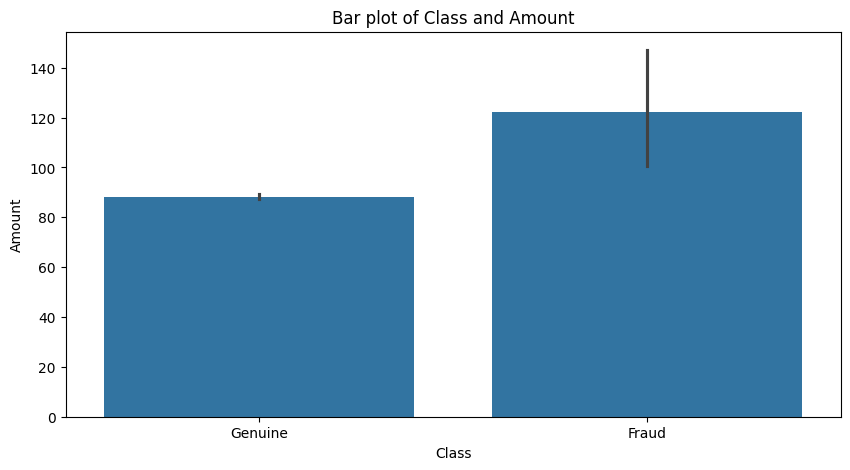

In [39]:
# Bar plot of Class_o and Amount
fig = plt.figure(figsize=(10, 5))
sns.barplot(x='Class', y='Amount', data=credit_card_data)
plt.xticks([0, 1], ['Genuine', 'Fraud'])
plt.xlabel('Class')
plt.ylabel('Amount')
plt.title('Bar plot of Class and Amount')
plt.show()

Transactions involving unusually high amounts have higher chance of being fraudulent.

### **Visualize `Time` and `Class`**

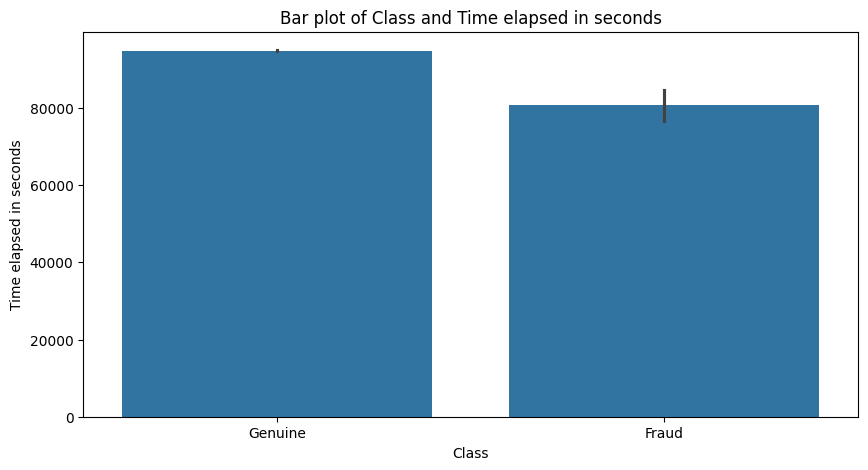

In [40]:
# Bar plot of Time and Class
fig = plt.figure(figsize=(10, 5))
sns.barplot(x='Class', y='Time', data=credit_card_data)
plt.xticks([0, 1], ['Genuine', 'Fraud'])
plt.xlabel('Class')
plt.ylabel('Time elapsed in seconds')
plt.title('Bar plot of Class and Time elapsed in seconds')
plt.show()

Fraudulent transactions are performed within shorter span of time with the longest fraudulent transaction performed within 22.22 hrs.

## **Preprocessing**

In [41]:
y = credit_card_data['Class']
X = credit_card_data.drop(columns='Class')

### **SMOTE Resampling**

In [42]:
sm = SMOTE(random_state=0)

In [43]:
X_re, y_re = sm.fit_resample(X, y)

In [44]:
y_re.value_counts()

,count
Class,
0,284315
1,284315


### **Train Test split**

In [45]:
X_train, X_val, y_train, y_val = train_test_split(X_re, y_re, train_size=0.7, test_size=0.3, random_state=0)

In [46]:
X_train.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
212637,138937.000000,-0.217237,1.214642,-0.867900,-0.534643,0.705577,-0.789080,0.598961,0.338160,-0.181912,...,-0.067125,-0.307740,-0.899593,0.138107,0.365361,-0.370734,0.127667,0.094900,0.012701,8.990000
535831,101051.718404,-19.763504,14.657189,-18.700233,9.004627,-11.041375,2.600133,-26.559146,-21.157768,-7.524045,...,4.961726,-9.722071,3.206752,2.290377,0.075709,-0.272550,-0.095071,-3.260632,0.268431,1.790901
182914,125582.000000,-1.133353,0.807346,0.335179,-0.246120,1.907576,-0.457185,1.363960,-0.107106,-0.527933,...,-0.281522,0.002291,-0.095884,-0.657837,0.141620,1.370342,-0.455861,-0.146808,0.065861,16.950000
402648,8039.006798,-0.284948,3.704714,-5.887135,5.031413,-0.138782,-2.332681,-2.439738,0.997800,-1.816243,...,0.405052,0.434186,-0.178306,0.092286,-0.323915,-0.477181,0.382597,0.452655,0.141150,1.000000
80440,58488.000000,-0.405486,1.045438,1.157308,-0.183143,0.467022,0.003578,0.542278,0.215311,-0.685132,...,0.124452,-0.202287,-0.496122,-0.042902,-0.350461,-0.208719,0.103399,0.260089,0.082109,2.670000


In [47]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 398041 entries, 212637 to 305711
Data columns (total 30 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    398041 non-null  float64
 1   V1      398041 non-null  float64
 2   V2      398041 non-null  float64
 3   V3      398041 non-null  float64
 4   V4      398041 non-null  float64
 5   V5      398041 non-null  float64
 6   V6      398041 non-null  float64
 7   V7      398041 non-null  float64
 8   V8      398041 non-null  float64
 9   V9      398041 non-null  float64
 10  V10     398041 non-null  float64
 11  V11     398041 non-null  float64
 12  V12     398041 non-null  float64
 13  V13     398041 non-null  float64
 14  V14     398041 non-null  float64
 15  V15     398041 non-null  float64
 16  V16     398041 non-null  float64
 17  V17     398041 non-null  float64
 18  V18     398041 non-null  float64
 19  V19     398041 non-null  float64
 20  V20     398041 non-null  float64
 21  V21     39

In [48]:
y_train.head()

,Class
212637,0
535831,1
182914,0
402648,1
80440,0


In [49]:
y_train.value_counts()

,count
Class,
0,199143
1,198898


### **Standard Scaler**

In [50]:
ss = StandardScaler()

In [51]:
X_train['Amount'] = ss.fit_transform(pd.DataFrame(X_train['Amount']))
X_val['Amount'] = ss.transform(pd.DataFrame(X_val['Amount']))

In [52]:
X_train.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
212637,138937.000000,-0.217237,1.214642,-0.867900,-0.534643,0.705577,-0.789080,0.598961,0.338160,-0.181912,...,-0.067125,-0.307740,-0.899593,0.138107,0.365361,-0.370734,0.127667,0.094900,0.012701,-0.396571
535831,101051.718404,-19.763504,14.657189,-18.700233,9.004627,-11.041375,2.600133,-26.559146,-21.157768,-7.524045,...,4.961726,-9.722071,3.206752,2.290377,0.075709,-0.272550,-0.095071,-3.260632,0.268431,-0.429548
182914,125582.000000,-1.133353,0.807346,0.335179,-0.246120,1.907576,-0.457185,1.363960,-0.107106,-0.527933,...,-0.281522,0.002291,-0.095884,-0.657837,0.141620,1.370342,-0.455861,-0.146808,0.065861,-0.360109
402648,8039.006798,-0.284948,3.704714,-5.887135,5.031413,-0.138782,-2.332681,-2.439738,0.997800,-1.816243,...,0.405052,0.434186,-0.178306,0.092286,-0.323915,-0.477181,0.382597,0.452655,0.141150,-0.433171
80440,58488.000000,-0.405486,1.045438,1.157308,-0.183143,0.467022,0.003578,0.542278,0.215311,-0.685132,...,0.124452,-0.202287,-0.496122,-0.042902,-0.350461,-0.208719,0.103399,0.260089,0.082109,-0.425521


## **Models**

### **Decision Tree Model**

**Train Decision Tree Model**

In [53]:
dt = DecisionTreeClassifier(max_depth=5, min_samples_leaf=5, random_state=0)

In [54]:
dt.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=5, min_samples_leaf=5, random_state=0)

**Make Prediction**

In [55]:
y_preds_dt = dt.predict(X_val)

In [56]:
y_preds_dt

array([1, 1, 1, ..., 1, 0, 1])

**Model Metrics**

In [73]:
# Accuracy
accuracy_dt = round(accuracy_score(y_preds_dt, y_val), 3)
print(f"Accuracy = {accuracy_dt}")

# Precision
precision_dt = round(precision_score(y_preds_dt, y_val), 3)
print(f'Precision = {precision_dt}')

# Recall
recall_dt = round(recall_score(y_preds_dt, y_val), 3)
print(f'Recall = {recall_dt}')

# F1
f1_dt = round(f1_score(y_preds_dt, y_val), 3)
print(f'F1 score = {f1_dt}')

# ROC AUC score
roc_auc_dt = round(roc_auc_score(y_preds_dt, y_val), 3)
print(f"ROC AUC Score = {roc_auc_dt}")

# Confusion Matrix
cm_dt = confusion_matrix(y_preds_dt, y_val)
print(f"Confusion Matrix = \n{cm_dt}\n")

# Classification Report
cr_dt = classification_report(y_preds_dt, y_val)
print(f"Classification Report = \n{cr_dt}\n")

Accuracy = 0.97
Precision = 0.959
Recall = 0.98
F1 score = 0.97
ROC AUC Score = 0.97
Confusion Matrix = 
[[83542  3466]
 [ 1630 81951]]

Classification Report = 
              precision    recall  f1-score   support

           0       0.98      0.96      0.97     87008
           1       0.96      0.98      0.97     83581

    accuracy                           0.97    170589
   macro avg       0.97      0.97      0.97    170589
weighted avg       0.97      0.97      0.97    170589




### **Random Forest Model**

**Train Random Forest Model**

In [64]:
rf = RandomForestClassifier(max_depth=10, random_state=0)

In [65]:
rf.fit(X_train, y_train)

RandomForestClassifier(max_depth=10, random_state=0)

**Make Prediction**

In [66]:
y_preds_rf = rf.predict(X_val)

In [67]:
y_preds_rf

array([1, 1, 1, ..., 1, 0, 1])

**Model Metrics**

In [74]:
# Accuracy
accuracy_rf = round(accuracy_score(y_preds_rf, y_val), 3)

# Precision
precision_rf = round(precision_score(y_preds_rf, y_val), 3)
print(f'Precision = {precision_rf}')

# Recall
recall_rf = round(recall_score(y_preds_rf, y_val), 3)
print(f'Recall = {recall_rf}')

# F1
f1_rf = round(f1_score(y_preds_rf, y_val), 3)
print(f'F1 = {f1_rf}')

# ROC AUC Score
roc_auc_rf = round(roc_auc_score(y_preds_rf, y_val), 3)
print(f"ROC AUC Score = {roc_auc_rf}")

# Confusion Matrix
cm_rf = confusion_matrix(y_preds_rf, y_val)
print(f"Confusion Matrix = \n{cm_rf}\n")

# Classification Report
cr_rf = classification_report(y_preds_rf, y_val)
print(f"Classification Report = \n{cr_rf}\n")

Precision = 0.983
Recall = 0.999
F1 = 0.991
ROC AUC Score = 0.991
Confusion Matrix = 
[[85064  1431]
 [  108 83986]]

Classification Report = 
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     86495
           1       0.98      1.00      0.99     84094

    accuracy                           0.99    170589
   macro avg       0.99      0.99      0.99    170589
weighted avg       0.99      0.99      0.99    170589




## **Plotting the results**

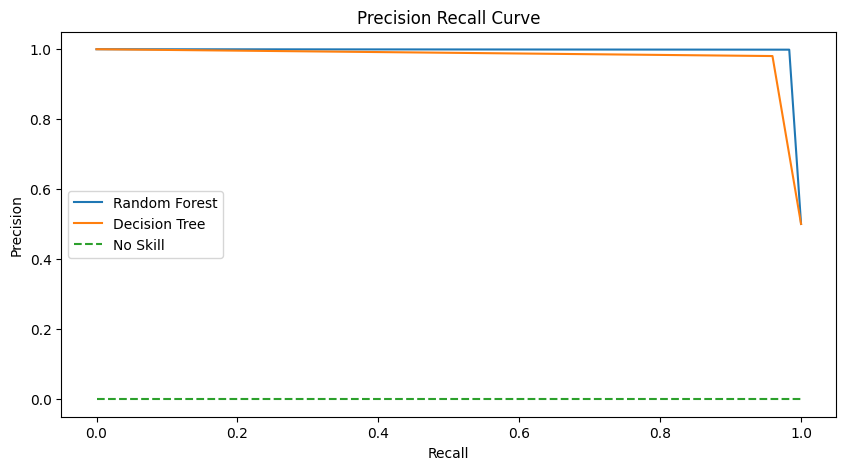

In [69]:
prec_dt, rec_dt, threshold_prec_dt = precision_recall_curve(y_true=y_val, y_score=y_preds_dt)
prec_rf, rec_rf, threshold_prec_rf = precision_recall_curve(y_true=y_val, y_score=y_preds_rf)

# Precision Recall Curve
fig = plt.figure(figsize=(10, 5))
sns.lineplot(x=rec_rf, y=prec_rf, label='Random Forest')
sns.lineplot(x=rec_dt, y=prec_dt, label='Decision Tree')
plt.plot([0, 1], [0, 0], linestyle='--', label='No Skill')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision Recall Curve')
plt.legend()
plt.show()

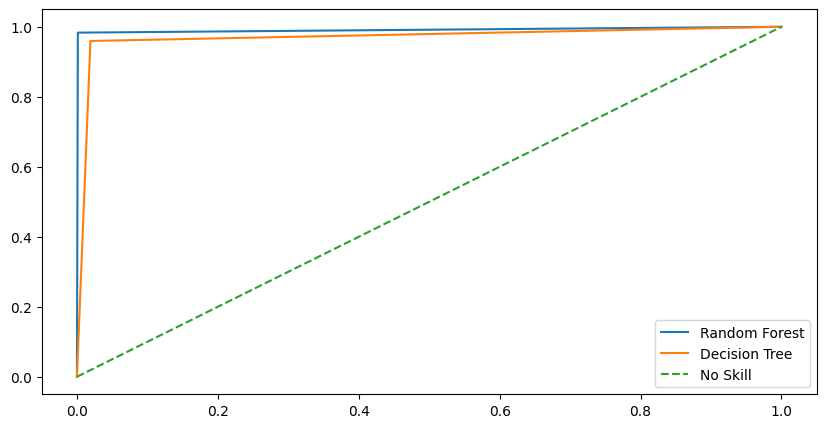

In [87]:
fpr_dt, tpr_dt, threshold_dt = roc_curve(y_true=y_val, y_score=y_preds_dt)
fpr_rf, tpr_rf, threshold_rf = roc_curve(y_true=y_val, y_score=y_preds_rf)

# ROC AUC Curve
fig = plt.figure(figsize=(10, 5))
sns.lineplot(x=fpr_rf, y=tpr_rf, label="Random Forest")
sns.lineplot(x=fpr_dt, y=tpr_dt, label="Decision Tree")
plt.plot([0, 1], [0, 1], linestyle="--", label="No Skill")
plt.legend()
plt.show()

Random Forest is the best model for this data.